In [363]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('/Users/jakemahoney/PycharmProjects/spotify_data_analysis/data/spotify_data_clean.csv')
df['album_release_date'] = pd.to_datetime(df['album_release_date'])

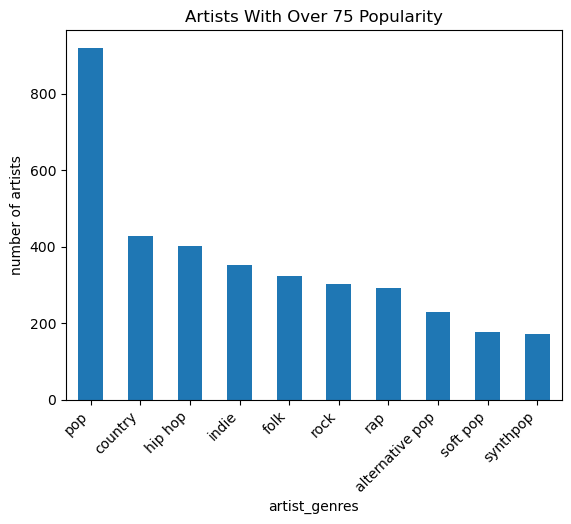

In [364]:
#Creates a bar chart from given attribute. Handles instances with not data and instances that fit into multiple categories
def genre_bar_chart(df, attribute, limit):
    cleaned=df.dropna(subset=[attribute]).copy()
    cleaned[attribute]=cleaned[attribute].str.split(',')
    cleaned=cleaned.explode(attribute)
    cleaned[attribute]=cleaned[attribute].astype(str).str.strip()
    counts=cleaned[attribute].value_counts()
    counts.iloc[0:limit].plot(kind='bar')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(attribute)
    plt.ylabel('number of artists')

#Uses genre_bar_chart to create graphs for given popularity ranges
most_popular_artists=df[df['artist_popularity']>=75]
genre_bar_chart(most_popular_artists, 'artist_genres', 10) 
plt.title('Artists With Over 75 Popularity')
plt.show()



These graphs show the top ten most popular genres for artists with a popularity of over 75. There are by far the most famous pop artists, at well over 800, more than double the next highest genre. Country and hip hop are the second and third most popular, with numbers around 400 artists. Moving down towards genres with fewer popular artists, there is no other major drop off like after pop, but a smoother decrease in the number of artists.

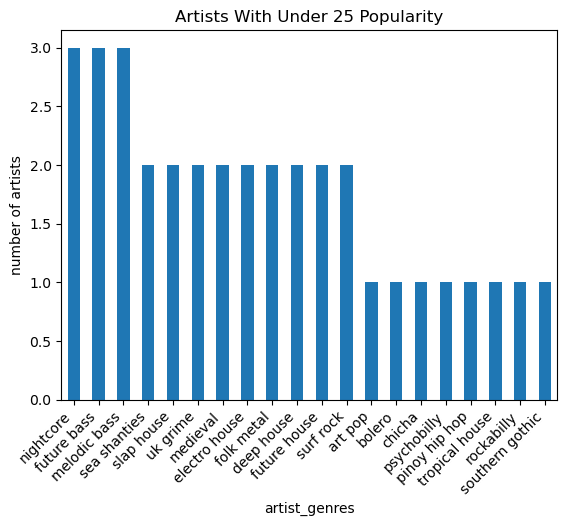

In [365]:
least_popular_artists=df[df['artist_popularity']<=25]
genre_bar_chart(least_popular_artists, 'artist_genres', 20)
plt.title('Artists With Under 25 Popularity')
plt.show()

Here we can see the 20 most common genres for artists with less than 25 popularity. These genres are mostly what would be considered niche, and only have a few people making music in the genre. This trend would suggest that people making music in less popular genres tend to be less popular artists as well. 

Text(0, 0.5, 'Percentage of Songs')

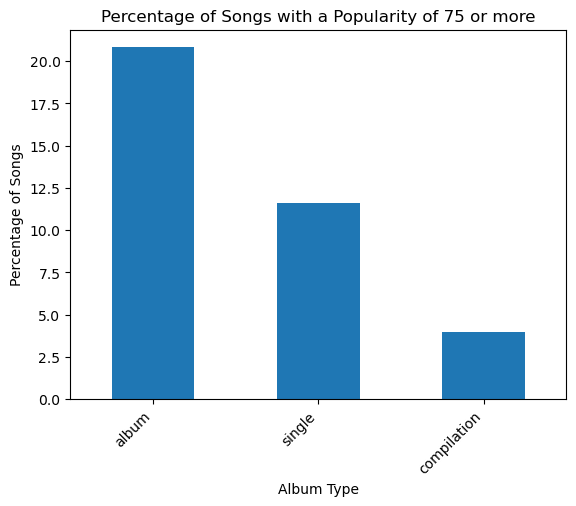

In [366]:
#calculates relative rate of popularity for album types by dividing the amount of songs with popularity above 75 over total number of song in category 
most_popular_tracks=df[df['track_popularity']>=75]
album_type_counts=df['album_type'].value_counts()
pop_album_type_counts=most_popular_tracks['album_type'].value_counts()
relative_pop=(pop_album_type_counts/album_type_counts)*100

relative_pop.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Songs with a Popularity of 75 or more')
plt.xlabel('Album Type')
plt.ylabel('Percentage of Songs')

This chart shows what percentage of songs reach a popularity based on how they were released. Songs that are released as part of an album have the highest chance to become popular, with a little over 20% surpassing a 75 popularity. Songs released as singles drop down to only about 12%, and songs that are a part of a compilation have only a 5% chance of being over a 75 popularity.

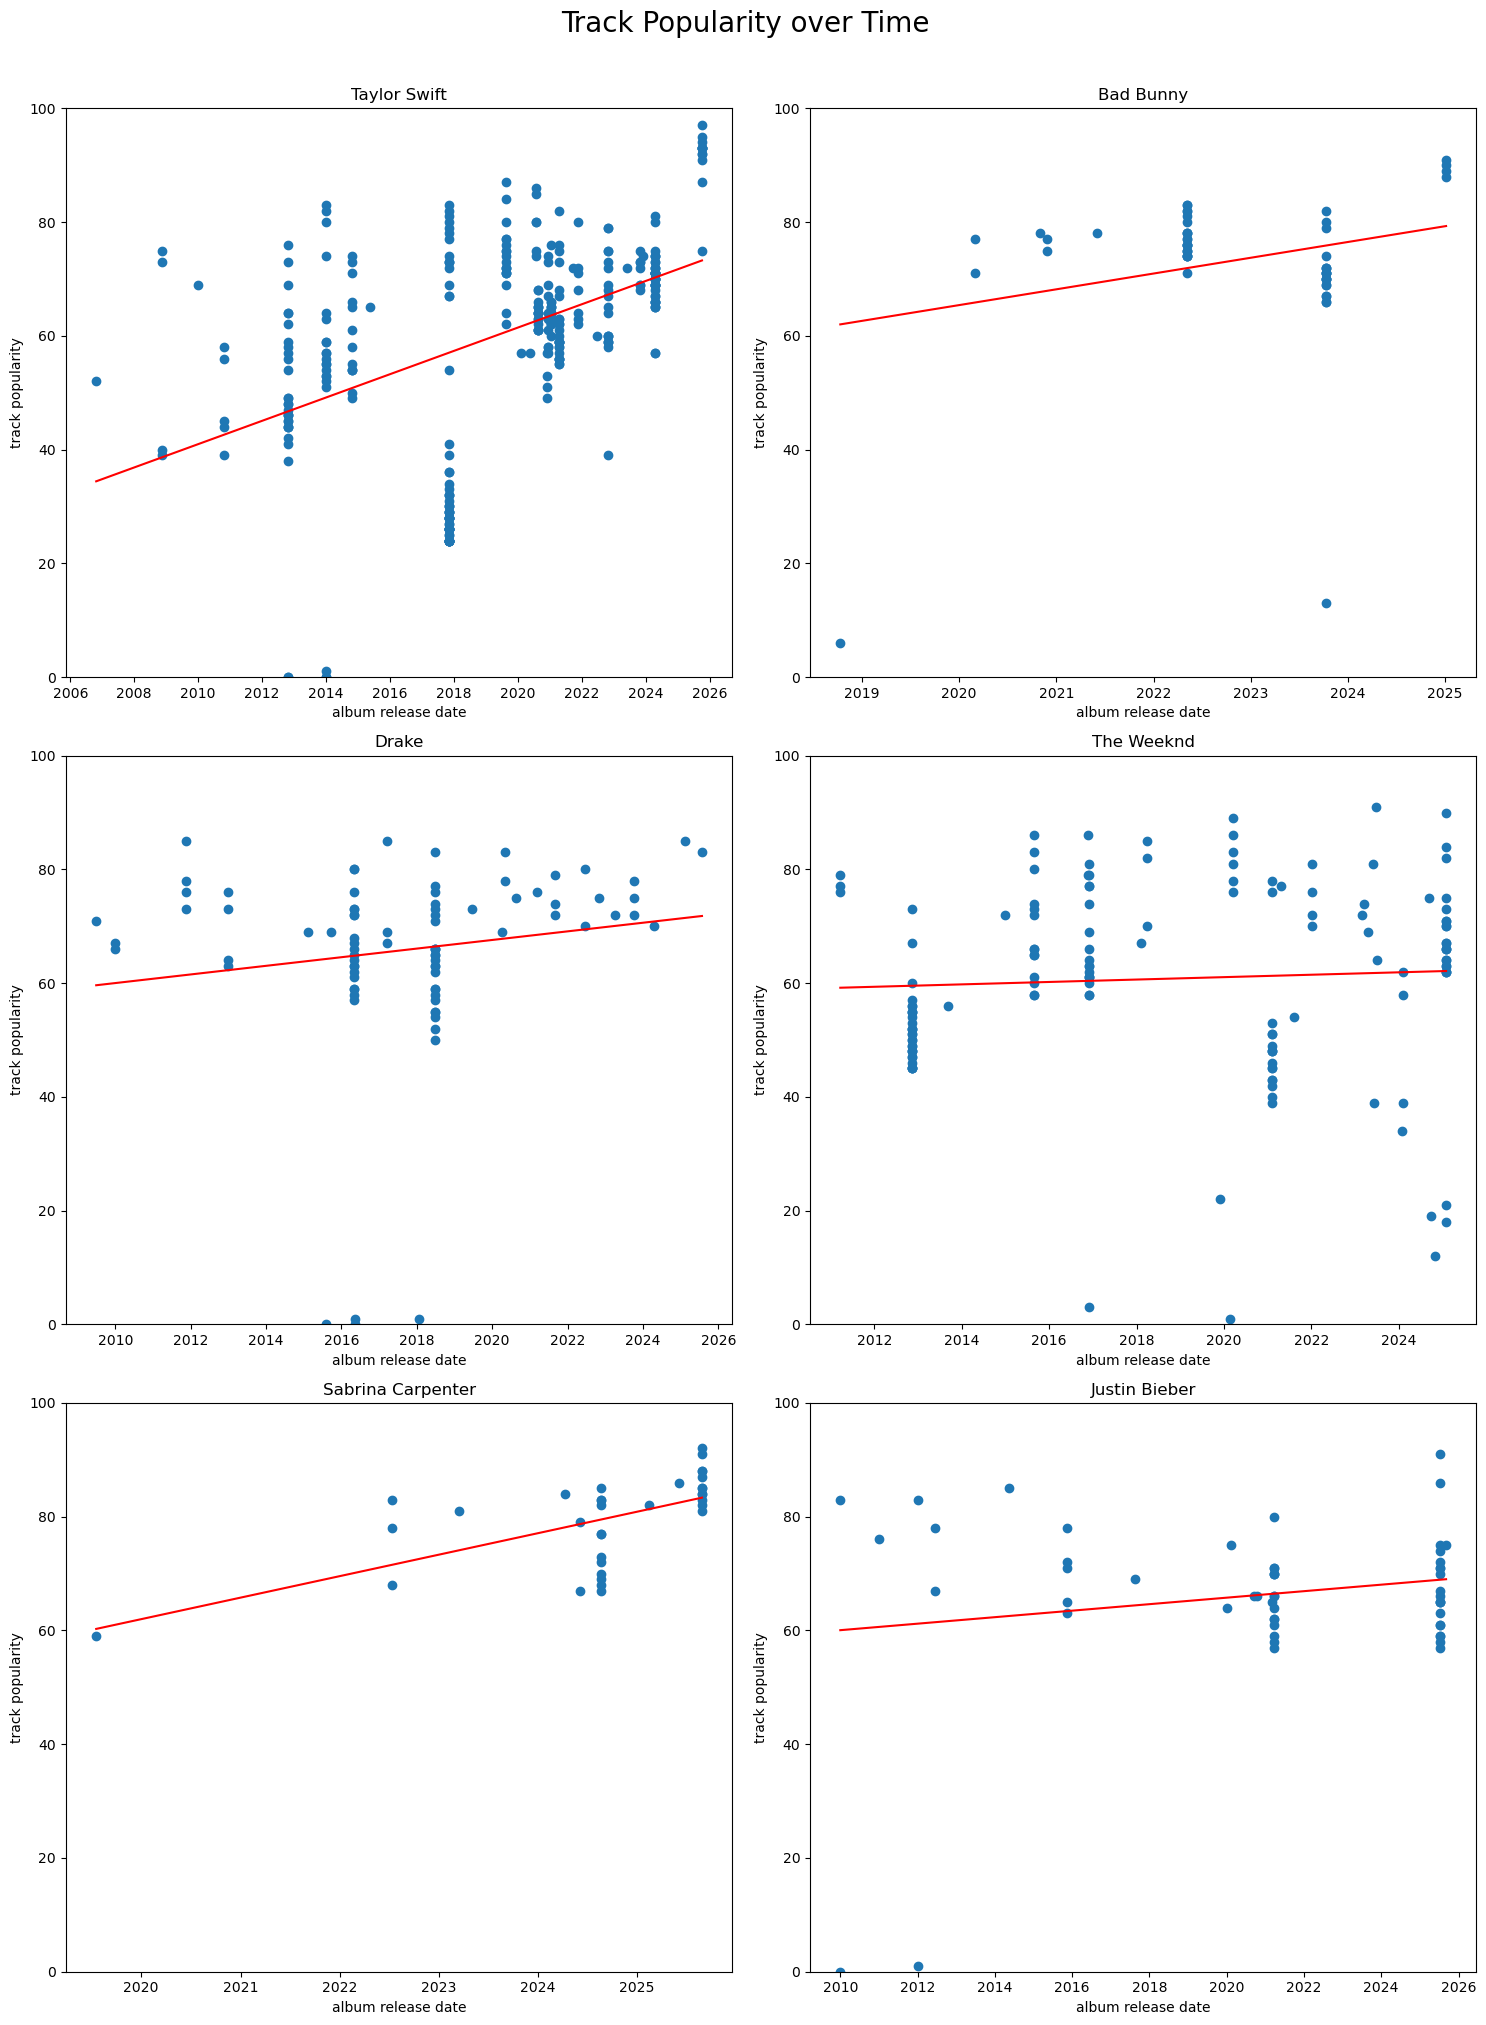

In [367]:
#creates an ordered list by artist popularity
rankings = df.groupby('artist_name')['artist_popularity'].max()
rankings = rankings.sort_values(ascending=False)  
top_6=rankings[0:6].index.tolist()

#Creates a scatter plot of track popularity vs release date
#arranges them as subplots all onto the same figure
#adds a trendline showing change in popularity over time
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))
axes = axes.flatten()
fig.suptitle('Track Popularity over Time', fontsize=20, y=1.01)
for i,index in enumerate(top_6):
    disco=df.loc[df['artist_name'] == index]
    ax=axes[i]
    ax.scatter(disco['album_release_date'], disco['track_popularity'])
    ax.set_xlabel('album release date')
    ax.set_ylabel('track popularity')
    ax.set_ylim(0,100)
    ax.set_title(index)
    z=np.polyfit(mdates.date2num(disco['album_release_date']), disco['track_popularity'], 1)
    p=np.poly1d(z)
    ax.plot(disco['album_release_date'], p(mdates.date2num(disco['album_release_date'])), color='red')
plt.tight_layout()
plt.show()

These charts examine the history of the six most popular artists on spotify. While the distribution of individual track popularity varies between artists, all of their trend lines have stayed around at least 60 for popularity. The only artists ever notably below 60 was Taylor Swift prior to the 2020s, but her trendline has the steepest increase in popularity of all the shown artists. This data would suggest that maintaining an average song popularity of 60 is a strong indicator of becoming a popular artist.

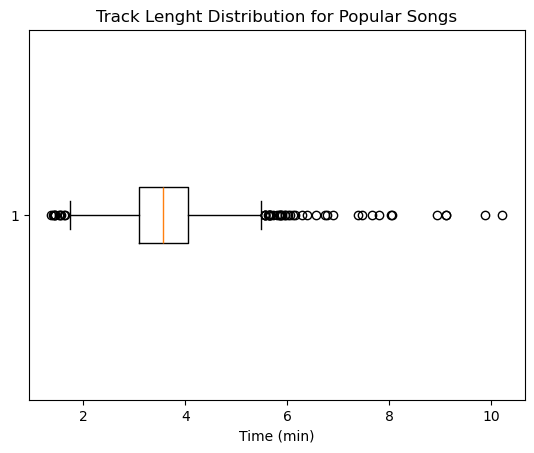

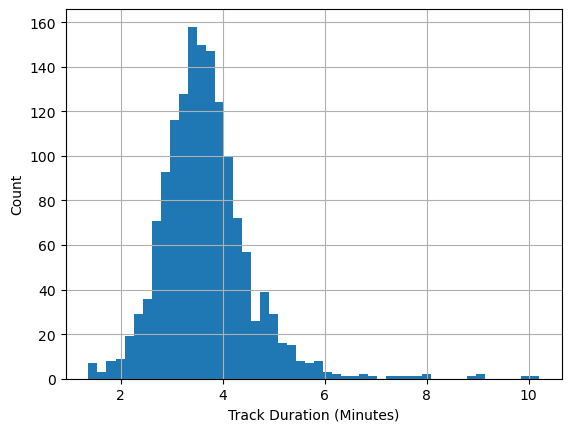

Average Track lenght: 3.655835561497326 
Standard Deviation: 0.8879001403477287
Quartile 1: 3.1 
Median Track duration: 3.57 
Quartile 3: 4.06


In [368]:
plt.title('Track Lenght Distribution for Popular Songs')
plt.boxplot(most_popular_tracks['track_duration_min'], vert=False)
plt.xlabel('Time (min)')
plt.show()
most_popular_tracks['track_duration_min'].hist(bins=50)
plt.xlabel('Track Duration (Minutes)')
plt.ylabel('Count')
plt.show()

time_mean=most_popular_tracks['track_duration_min'].mean()
time_std=most_popular_tracks['track_duration_min'].std()
time_min=most_popular_tracks['track_duration_min'].min()
time_q1=most_popular_tracks['track_duration_min'].quantile(0.25)
time_median=most_popular_tracks['track_duration_min'].median()
time_q3=most_popular_tracks['track_duration_min'].quantile(0.75)
time_max=most_popular_tracks['track_duration_min'].max()
print(f"Average Track lenght: {time_mean} "
      f"\nStandard Deviation: {time_std}"
      f"\nQuartile 1: {time_q1} "
      f"\nMedian Track duration: {time_median} "
      f"\nQuartile 3: {time_q3}")

In these charts the distribution of songs with a popularity of over 75 is graphed based on the track duration. The median and mean are both around 3.6 minutes, with a very tight distribution around this point. About 50% of these popular songs are withing 3-4 minutes, and exceedingly few fall outside 2-5 minutes. This data supports the idea that keeping songs close to 3.6 minutes will greatly increase the odds of it becoming popular. 

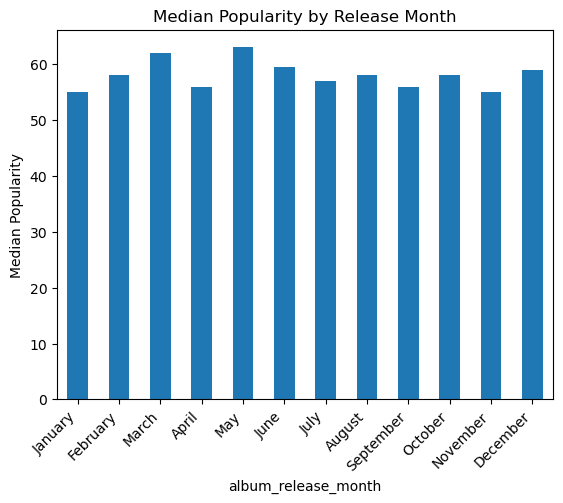

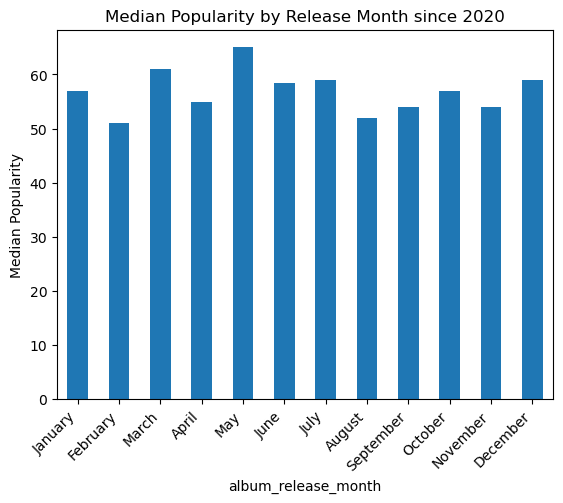

In [369]:
#creates a copy of the original data frame with columns added separately for month and year of release
history=df.copy()
history['album_release_month']=history['album_release_date'].dt.month_name()
history['album_release_year']=history['album_release_date'].dt.year
calendar=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

#groups songs together that were released in the same month and finds the mean popularity  
months_grouped=history.groupby('album_release_month')['track_popularity'].median()
months_grouped=months_grouped.reindex(calendar)
last5_grouped = history[history['album_release_year'] >=2020]
last5_grouped=last5_grouped.groupby('album_release_month')['track_popularity'].median()
last5_grouped=last5_grouped.reindex(calendar)

months_grouped.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Popularity')
plt.title("Median Popularity by Release Month")
plt.show()

last5_grouped.plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Popularity')
plt.title("Median Popularity by Release Month since 2020")
plt.show()

In these graphs the median popularity of songs each month are calculated. The first one takes data across all years represented in the data, while the second one takes only data since 2020. Through these graphs we can conserve that the median popularity stays steadily between 50 and 60 throughout the year. Both charts shows May being the time the mos popular songs are released, as well april having a significantly lower median popularity than its neighbouring months. Since 2020, a stronger correlation between release month and popularity can be seen. May-July releases appears to correlate to higher popularity, whereas months such as February and april have lower popularity. This would suggest that timing a release for specific months could help to increase the song's popularity. 






    
